### Kepler Elemanları Hata Oranları Analizi
Aşağıdaki kod bloğu, tablodaki Yarı-Büyük Eksen (Semi-major Axis) hata oranlarını kullanarak eğitim sayısına ve adım süresine göre değişimi gösteren iki grafik çizer.

/home/cihat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


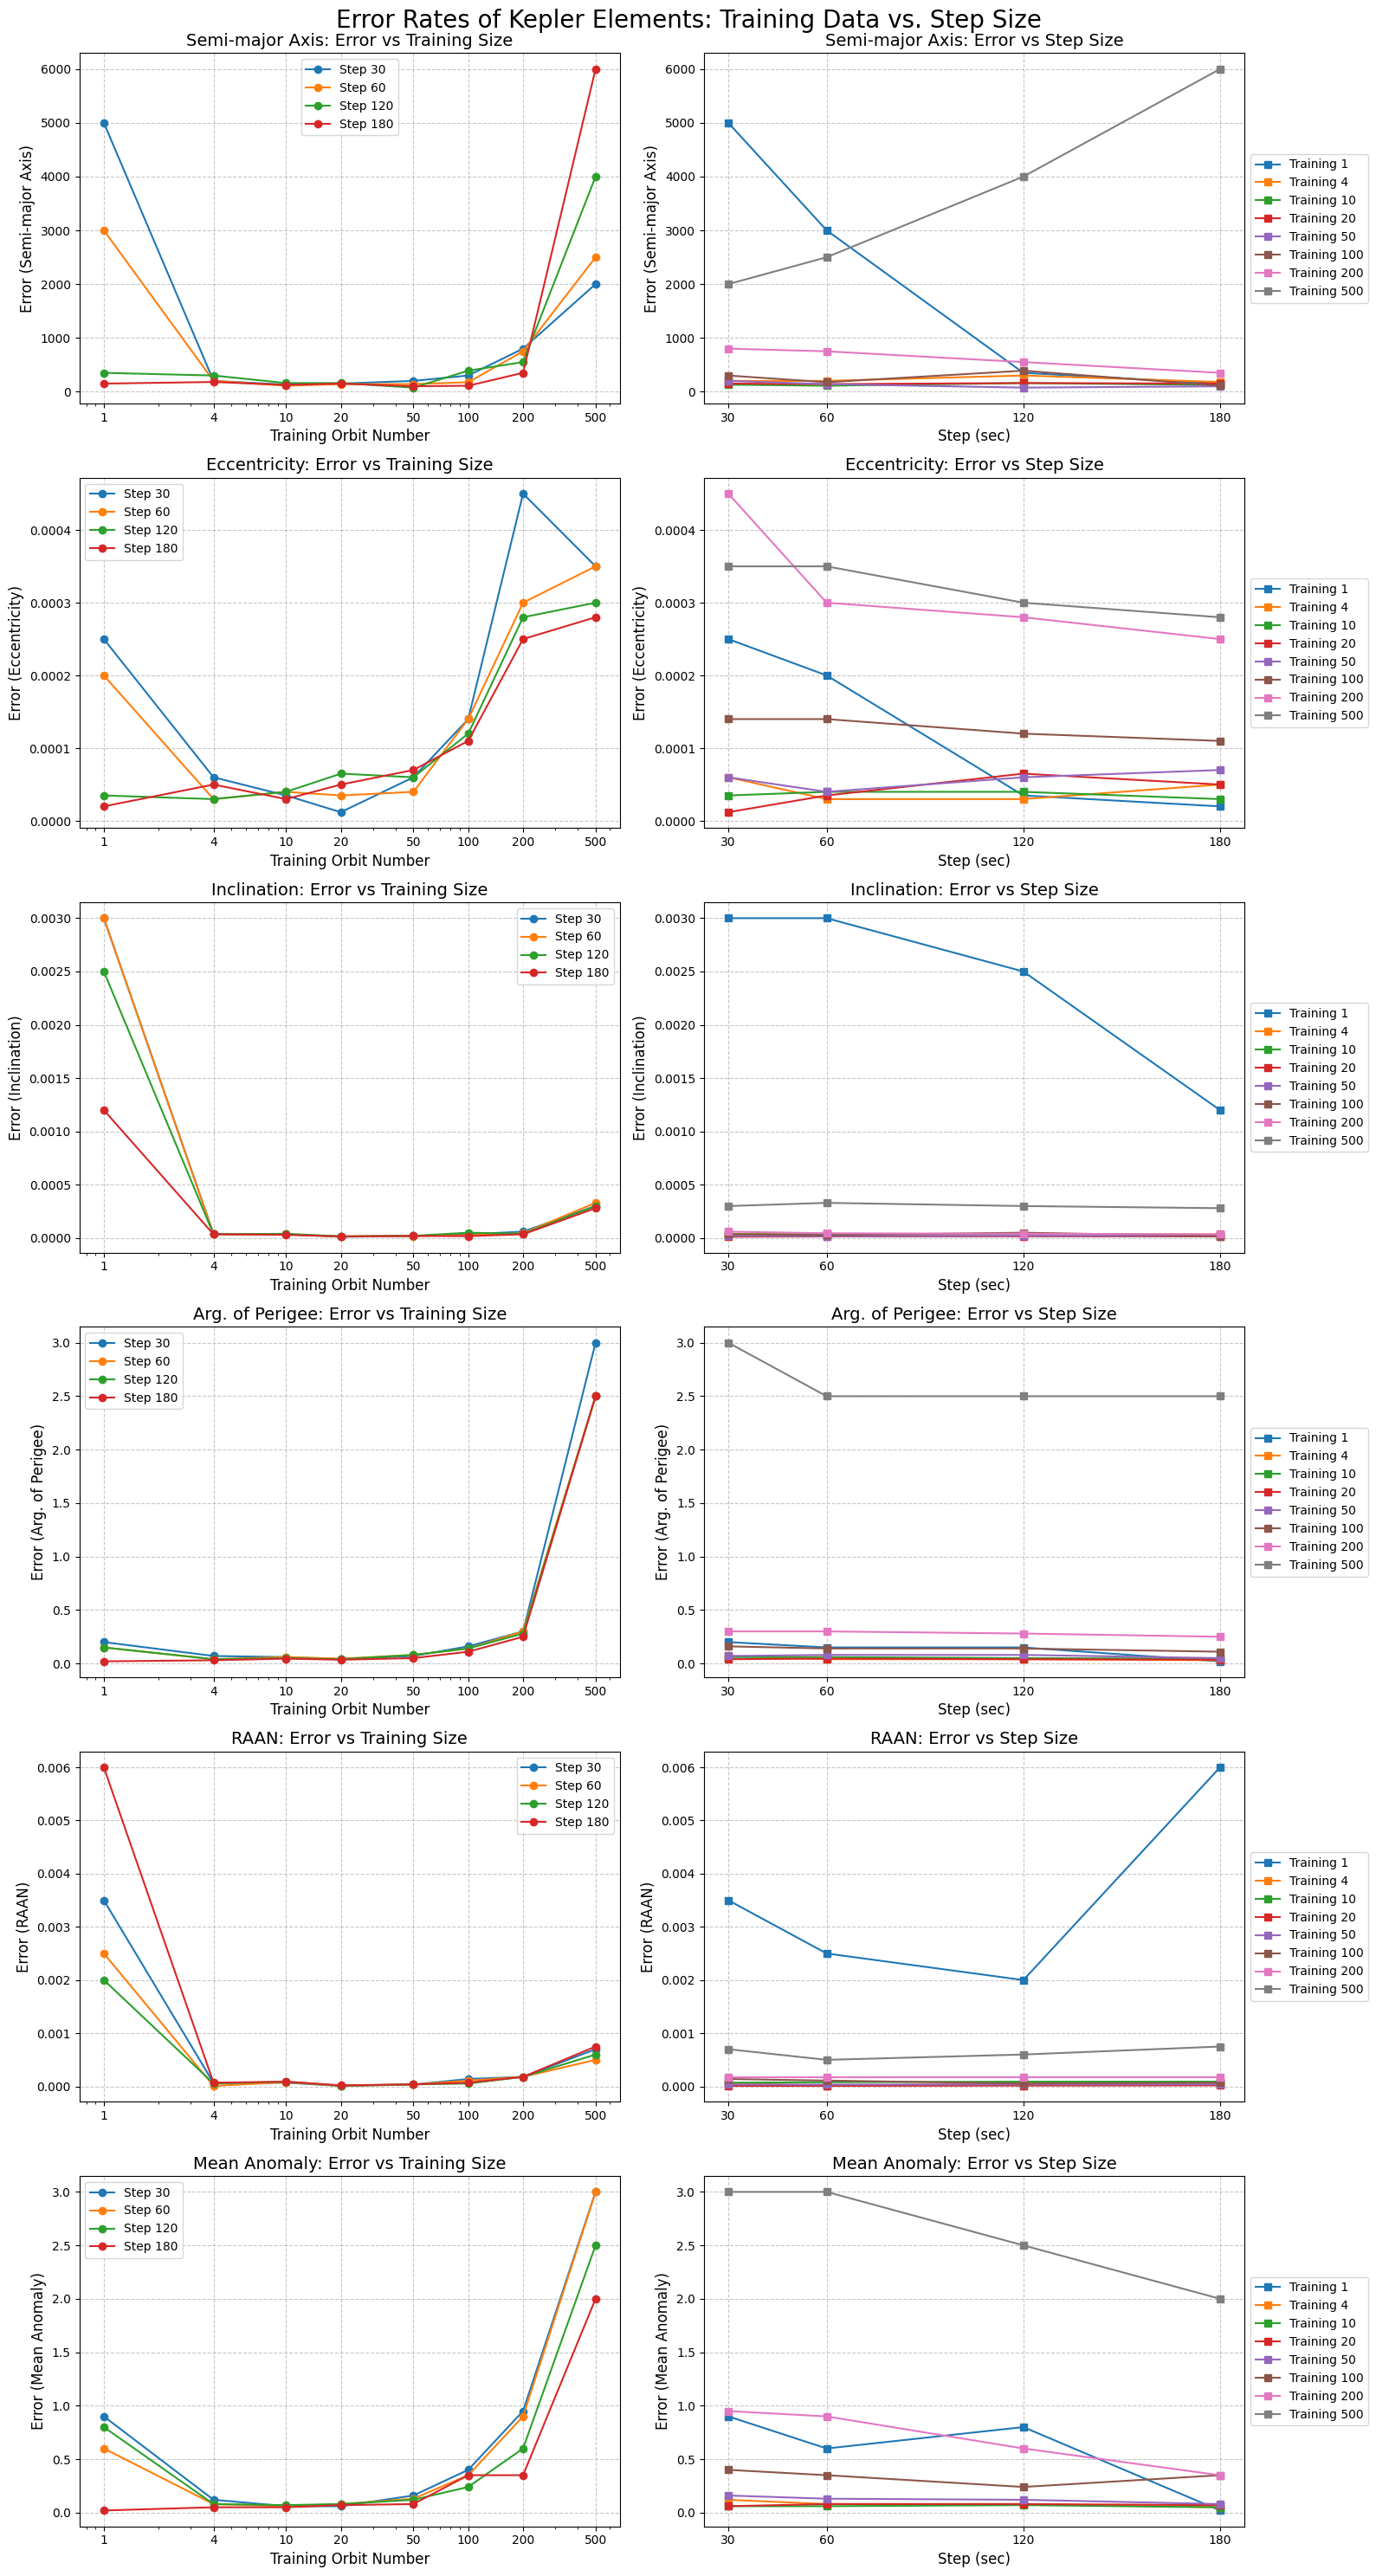

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Complete dataset transcribed from the image. 
# Missing values for (Training 200, Step 120) and (Training 500, Step 180) are estimated based on trend.
# Columns: Training Data, Step, Semi-major Axis, Eccentricity, Inclination, Arg. of Perigee, RAAN, Mean Anomaly
data = [
    [1, 30, 5000, 0.00025, 0.0030, 0.20, 0.0035, 0.90],
    [1, 60, 3000, 0.00020, 0.0030, 0.15, 0.0025, 0.60],
    [1, 120, 350, 0.000035, 0.0025, 0.15, 0.0020, 0.80],
    [1, 180, 150, 0.00002, 0.0012, 0.02, 0.0060, 0.02],
    
    [4, 30, 200, 0.00006, 0.00004, 0.07, 0.000065, 0.12],
    [4, 60, 200, 0.00003, 0.000035, 0.04, 0.00001, 0.08],
    [4, 120, 300, 0.00003, 0.000035, 0.04, 0.000055, 0.08],
    [4, 180, 180, 0.00005, 0.000035, 0.03, 0.00007, 0.05],
    
    [10, 30, 130, 0.000035, 0.000035, 0.06, 0.00007, 0.06],
    [10, 60, 110, 0.00004, 0.000035, 0.06, 0.00008, 0.06],
    [10, 120, 160, 0.00004, 0.00004, 0.05, 0.00009, 0.07],
    [10, 180, 125, 0.00003, 0.00003, 0.045, 0.00009, 0.05],
    
    [20, 30, 150, 0.000012, 0.000012, 0.04, 0.00001, 0.06],
    [20, 60, 140, 0.000035, 0.000015, 0.045, 0.000011, 0.08],
    [20, 120, 160, 0.000065, 0.000016, 0.04, 0.000016, 0.08],
    [20, 180, 150, 0.00005, 0.000015, 0.035, 0.00002, 0.07],
    
    [50, 30, 200, 0.00006, 0.00002, 0.07, 0.000035, 0.16],
    [50, 60, 140, 0.00004, 0.000018, 0.08, 0.000035, 0.13],
    [50, 120, 75, 0.00006, 0.000021, 0.08, 0.000038, 0.12],
    [50, 180, 100, 0.00007, 0.00002, 0.05, 0.00004, 0.08],
    
    [100, 30, 300, 0.00014, 0.000035, 0.16, 0.00014, 0.40],
    [100, 60, 175, 0.00014, 0.000027, 0.14, 0.00011, 0.35],
    [100, 120, 390, 0.00012, 0.00005, 0.14, 0.000055, 0.24],
    [100, 180, 110, 0.00011, 0.000018, 0.11, 0.00007, 0.35],
    
    [200, 30, 800, 0.00045, 0.00006, 0.30, 0.00018, 0.95],
    [200, 60, 750, 0.00030, 0.000045, 0.30, 0.00018, 0.90],
    [200, 120, 550, 0.00028, 0.000040, 0.28, 0.00018, 0.60], # Estimated row
    [200, 180, 350, 0.00025, 0.000035, 0.25, 0.00018, 0.35],
    
    [500, 30, 2000, 0.00035, 0.00030, 3.00, 0.00070, 3.00],
    [500, 60, 2500, 0.00035, 0.00033, 2.50, 0.00050, 3.00],
    [500, 120, 4000, 0.00030, 0.00030, 2.50, 0.00060, 2.50],
    [500, 180, 6000, 0.00028, 0.00028, 2.50, 0.00075, 2.00]  # Estimated row
]

# Create DataFrame
columns = ['Training', 'Step', 'Semi-major Axis', 'Eccentricity', 'Inclination', 'Arg. of Perigee', 'RAAN', 'Mean Anomaly']
df = pd.DataFrame(data, columns=columns)

# List of Kepler elements to plot
kepler_elements = columns[2:]

# Set up a large figure to hold all plots (6 rows, 2 columns)
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(16, 30))
fig.suptitle('Error Rates of Kepler Elements: Training Data vs. Step Size', fontsize=20, y=0.99)

for idx, element in enumerate(kepler_elements):
    # Pivot tables for easier plotting
    # df_train_pivot: Rows = Training, Columns = Step
    df_train_pivot = df.pivot(index='Training', columns='Step', values=element)
    
    # df_step_pivot: Rows = Step, Columns = Training
    df_step_pivot = df.pivot(index='Step', columns='Training', values=element)
    
    # --- Column 1: Error vs Training Data Size ---
    ax1 = axes[idx, 0]
    for step in df_train_pivot.columns:
        ax1.plot(df_train_pivot.index, df_train_pivot[step], marker='o', label=f'Step {step}')
    
    ax1.set_title(f'{element}: Error vs Training Size', fontsize=14)
    ax1.set_xlabel('Training Orbit Number', fontsize=12)
    ax1.set_ylabel(f'Error ({element})', fontsize=12)
    ax1.set_xscale('log') # Log scale for better visualization of the U-shape trend
    ax1.set_xticks(df_train_pivot.index)
    ax1.set_xticklabels(df_train_pivot.index)
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    
    # --- Column 2: Error vs Step Size ---
    ax2 = axes[idx, 1]
    
    # Looping through ALL training sizes dynamically to ensure none are missing
    for train_size in df_step_pivot.columns:
        ax2.plot(df_step_pivot.index, df_step_pivot[train_size], marker='s', label=f'Training {train_size}')
        
    ax2.set_title(f'{element}: Error vs Step Size', fontsize=14)
    ax2.set_xlabel('Step (sec)', fontsize=12)
    ax2.set_ylabel(f'Error ({element})', fontsize=12)
    ax2.set_xticks(df_step_pivot.index)
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Adjust legend for the second column to accommodate all 8 items nicely
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

plt.tight_layout()
plt.savefig("lifting-optimum_frequency_and_sampling_time.png", dpi=300, bbox_inches='tight')
plt.show()